In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Optionnel : pour voir toutes les colonnes lors de l'affichage
pd.set_option('display.max_columns', None)
# Affichage du cleaned dataset pour les visualisations


# Nettoyage du dataset

Ce notebook contient le code pour nettoyer le dataset de données sur les retards de trains.


In [201]:
file_path = "project_dataset.csv"
df = pd.read_csv(file_path, sep=";", encoding="utf-8")

print(f"Nombre de lignes initiales : {len(df)}")
df.head()

Nombre de lignes initiales : 12070


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Commentaire retards à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,3.693179191,NaN,147.0,28.43673469,6.511117534,NaN,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,4.567119342,NaN,105.0,18.049,5.363539095,"Ce mois-ci, l'OD a été touchée par les inciden...",32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,0.286283186,NaN,19.0,24.73684211,2.938053097,NaN,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,0.98,NaN,58.0,33.72643678,5.292211221,NaN,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,3.229700855,NaN,89.0,14.59269663,4.882371795,NaN,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965


In [202]:
# On ne garde que les lignes où la Date commence par un chiffre (Année ou Jour)
# Cela élimine les lignes commençant par "Le ", "Note", etc.
df = df[df['Date'].astype(str).str.contains(r'^\d', na=False, regex=True)]

print(f"Nombre de lignes après filtrage des commentaires : {len(df)}")

Nombre de lignes après filtrage des commentaires : 12010


In [203]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Doublons supprimés : {initial_count - len(df)}")

Doublons supprimés : 190


In [204]:
numeric_cols = [
    "Durée moyenne du trajet", "Nombre de circulations prévues", "Nombre de trains annulés",
    "Nombre de trains en retard au départ", "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ", "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min", "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
    "Nombre trains en retard > 30min", "Nombre trains en retard > 60min",
    "Prct retard pour causes externes", "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic", "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
]

# Nettoyage et conversion numérique
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(",", ".").replace("-", np.nan)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Conversion de la date (format flexible)
df["Date"] = pd.to_datetime(df["Date"], format="mixed", errors="coerce")

# Suppression des éventuelles lignes où la date n'a pas pu être convertie
df = df.dropna(subset=['Date'])

# Création des colonnes pour faciliter l'analyse temporelle
df["Année"] = df["Date"].dt.year.astype(int)
df["Mois"] = df["Date"].dt.month.astype(int)

df.head()

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Commentaire retards à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",Année,Mois
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,NaN,289.0,11.247809,3.693179,NaN,147.0,28.436735,6.511118,NaN,110.0,6.510000,44.0,8.0,36.134454,31.092437,10.924370,15.966387,5.040000,0.840336,2018,1
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,NaN,213.0,8.479969,4.567119,NaN,105.0,18.049000,5.363539,"Ce mois-ci, l'OD a été touchée par les inciden...",32.0,5.363539,9.0,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,NaN,21.0,6.239683,0.286283,NaN,19.0,24.736842,2.938053,NaN,11.0,2.938053,6.0,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211,0.980000,NaN,58.0,33.726437,5.292211,NaN,39.0,5.292211,18.0,NaN,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,NaN,224.0,6.784673,3.229701,NaN,89.0,14.592697,4.882372,NaN,42.0,4.882372,10.0,0.0,15.789474,45.614035,NaN,15.789474,1.754386,1.754386,2018,1


In [205]:
# Remplissage des numériques par 0
df[numeric_cols] = df[numeric_cols].fillna(0)

# Remplissage des commentaires textuels
comment_cols = [
    "Commentaire annulations", 
    "Commentaire retards au départ", 
    "Commentaire retards à l'arrivée"
]
for col in comment_cols:
    df[col] = df[col].fillna("Non communiqué")

print("État final des valeurs manquantes :")
print(df.isnull().sum().sum())

État final des valeurs manquantes :
350


In [206]:
output_file = "cleaned_dataset.csv"
df.to_csv(output_file, index=False, sep=";", encoding="utf-8")

print(f"✅ Dataset nettoyé et prêt pour l'analyse : {output_file}")

✅ Dataset nettoyé et prêt pour l'analyse : cleaned_dataset.csv


# Visualisation et analyse des données 

Ce notebook contient le code pour visualiser les tendances, les distributions et les corrélations sur les retards de trains.

In [207]:
df = pd.read_csv("cleaned_dataset.csv", sep=';')
print(df.head())


         Date   Service      Gare de départ      Gare d'arrivée  \
0  2018-01-01  National    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
1  2018-01-01  National             LE MANS  PARIS MONTPARNASSE   
2  2018-01-01  National  PARIS MONTPARNASSE   LA ROCHELLE VILLE   
3  2018-01-01  National  PARIS MONTPARNASSE              NANTES   
4  2018-01-01  National            POITIERS  PARIS MONTPARNASSE   

   Durée moyenne du trajet  Nombre de circulations prévues  \
0                   141.00                           870.0   
1                    56.00                           406.0   
2                   166.00                           226.0   
3                   216.21                           508.0   
4                    94.00                           472.0   

   Nombre de trains annulés Commentaire annulations  \
0                       5.0          Non communiqué   
1                       1.0          Non communiqué   
2                       0.0          Non communiqué   
3   

In [208]:
# Affiche la liste complète des colonnes
print("Noms des colonnes dans ton dataset :")
print(df.columns.tolist())


Noms des colonnes dans ton dataset :
['Date', 'Service', 'Gare de départ', "Gare d'arrivée", 'Durée moyenne du trajet', 'Nombre de circulations prévues', 'Nombre de trains annulés', 'Commentaire annulations', 'Nombre de trains en retard au départ', 'Retard moyen des trains en retard au départ', 'Retard moyen de tous les trains au départ', 'Commentaire retards au départ', "Nombre de trains en retard à l'arrivée", "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée", "Commentaire retards à l'arrivée", 'Nombre trains en retard > 15min', 'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)', 'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min', 'Prct retard pour causes externes', 'Prct retard pour cause infrastructure', 'Prct retard pour cause gestion trafic', 'Prct retard pour cause matériel roulant', 'Prct retard pour cause gestion en gare et réutilisation de matériel', 'Prct retard pour cause prise en compte voya

Distribution des départs 

Nouveau minimum : 0
Nouveau maximum : 92


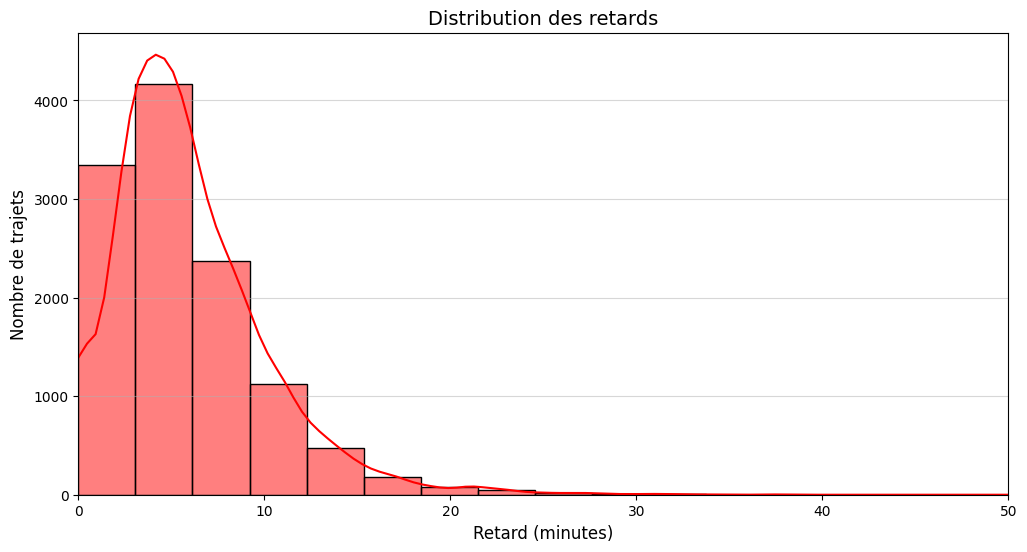

In [209]:
colonne_retard = "Retard moyen de tous les trains à l'arrivée"

# 1. Remplace les valeurs négatives par 0
df[colonne_retard] = df[colonne_retard].clip(lower=0)

# 2. Remplace les valeurs extrêmes (> 120 min) par la médiane
mediane = df[colonne_retard].median()
df[colonne_retard] = df[colonne_retard].apply(lambda x: mediane if x > 120 else x)

# 3. Arrondis les valeurs pour supprimer les décimales
df[colonne_retard] = df[colonne_retard].round().astype(int)

# 4. Vérifie le résultat
print(f"Nouveau minimum : {df[colonne_retard].min()}")
print(f"Nouveau maximum : {df[colonne_retard].max()}")

# 5. Refais la visualisation
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=colonne_retard, bins=30, kde=True, color='red')
plt.title(f"Distribution des retards", fontsize=14)
plt.xlabel("Retard (minutes)", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xlim(0, 50)
plt.grid(axis='y', alpha=0.5)
plt.show()


Nouveau minimum : 0
Nouveau maximum : 115


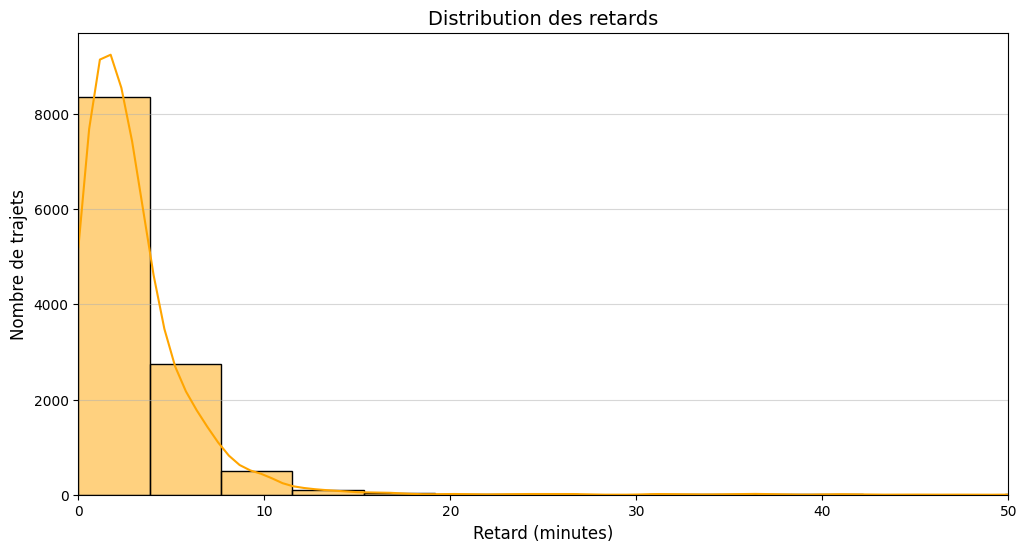

In [210]:
colonne_retard = "Retard moyen de tous les trains au départ"

# 1. Remplace les valeurs négatives par 0
df[colonne_retard] = df[colonne_retard].clip(lower=0)

# 2. Remplace les valeurs extrêmes (> 120 min) par la médiane
mediane = df[colonne_retard].median()
df[colonne_retard] = df[colonne_retard].apply(lambda x: mediane if x > 120 else x)

# 3. Arrondis les valeurs pour supprimer les décimales
df[colonne_retard] = df[colonne_retard].round().astype(int)

# 4. Vérifie le résultat
print(f"Nouveau minimum : {df[colonne_retard].min()}")
print(f"Nouveau maximum : {df[colonne_retard].max()}")

# 5. Refais la visualisation
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=colonne_retard, bins=30, kde=True, color='orange')
plt.title(f"Distribution des retards", fontsize=14)
plt.xlabel("Retard (minutes)", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xlim(0, 50)
plt.grid(axis='y', alpha=0.5)
plt.show()
